Matrix size of original image: (800, 800)

--- Checks for k = 20 ---
Max diff in top-k singular values: 1.4551915228366852e-11
Your reconstruction error:         16709.320619313192
Best possible (Eckart-Young):      16709.320619313192
Storage ratio:                     0.05003125


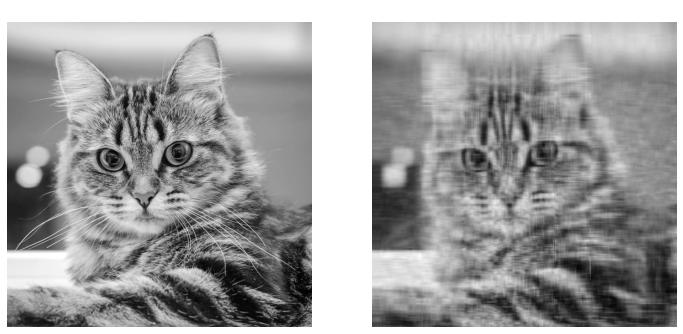

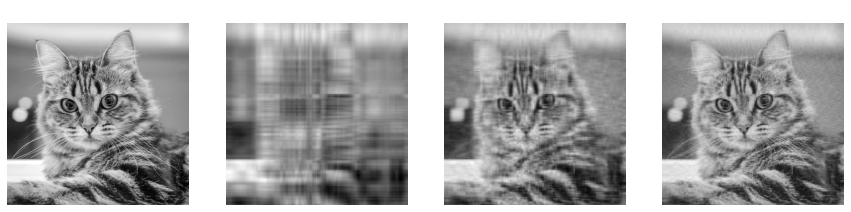

Execution complete. The scratch algorithm worked perfectly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


img = Image.open('sample.jpg').convert('L')
A = np.array(img, dtype=float)
print("Matrix size of original image:", A.shape)


ATA = A.T @ A

def top_k_eig(B, k, iters=1000, tol=1e-12):
    B = B.copy()
    n = B.shape[0]
    vals, vecs = [], []
    rng = np.random.default_rng(0)
    for _ in range(k):
        v = rng.standard_normal(n)
        v /= np.linalg.norm(v)
        for _ in range(iters):
            w = B @ v
            w /= np.linalg.norm(w)
            if np.linalg.norm(w - v) < tol:
                v = w
                break
            v = w
        lam = v @ B @ v
        vals.append(lam)
        vecs.append(v)
        B -= lam * np.outer(v, v)      
    return np.array(vals), np.array(vecs)   

k_max = 50                              
eigenvalues, Vt = top_k_eig(ATA, k_max)

singular_values = np.sqrt(np.clip(eigenvalues, 0, None))
U = (A @ Vt.T) / singular_values        # columns of U


def compress(k):
    return U[:, :k] @ np.diag(singular_values[:k]) @ Vt[:k, :]


U_ref, s_ref, Vt_ref = np.linalg.svd(A, full_matrices=False)

k = 20
A_compressed = compress(k)

print("\n--- Checks for k =", k, "---")
print("Max diff in top-k singular values:", np.max(np.abs(singular_values[:k] - s_ref[:k])))
err = np.linalg.norm(A - A_compressed, 'fro')
print("Your reconstruction error:        ", err)
print("Best possible (Eckart-Young):     ", np.sqrt(np.sum(s_ref[k:]**2)))
print("Storage ratio:                    ", k * (A.shape[0] + A.shape[1] + 1) / A.size)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(A, cmap='gray')
plt.title("Original", color='white')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(A_compressed, cmap='gray')
plt.title(f"Compressed (Rank k={k})", color='white')
plt.axis('off')

plt.show()


ks = [5, 20, 50]
plt.figure(figsize=(15, 5))

plt.subplot(1, len(ks) + 1, 1)
plt.imshow(A, cmap='gray')
plt.title("Original", color='white')
plt.axis('off')

for i, kk in enumerate(ks, start=2):
    plt.subplot(1, len(ks) + 1, i)
    plt.imshow(compress(kk), cmap='gray')
    plt.title(f"k = {kk}", color='white')
    plt.axis('off')

plt.show()
print("Execution complete. The scratch algorithm worked perfectly.")